In [1]:
import pandas as pd
import numpy as np
import math

from scipy.optimize import minimize, brentq, NonlinearConstraint, Bounds
from scipy import stats
from scipy.stats import norm
from scipy.interpolate import Rbf

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
from sympy import symbols, sqrt, simplify, expand, collect, solve
from sympy import Eq, Rational

In [3]:
from preprocessingUtil import *

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
np.random.seed(42)  # for reproducibility

## SPX Options, EOD Data, 2022, 2023

In [ ]:
df = process_raw_eod_data("data/eod/", verbose=True)

In [ ]:
df.columns  = df.columns.str.replace('[', '').str.replace(']', '').str.lower()
df.index = df.index.str.strip()
df.index.name = df.index.name.replace('[', '').replace(']', '').lower()

In [ ]:
df.columns

In [ ]:
df = df[df["dte"]>=14]

df["c_mid"] = (df["c_ask"] + df["c_bid"])/2
df["p_mid"] = (df["p_ask"] + df["p_bid"])/2
df["T"] = df["dte"]/365

df["c_spread"] = abs(df["c_ask"]-df["c_bid"])
df["c_spread_pct"] = 100*df["c_spread"]/df["c_mid"]
df["p_spread"] = abs(df["p_ask"]-df["p_bid"])
df["p_spread_pct"] = 100*df["p_spread"]/df["p_mid"]

liquid = df[(df["c_spread_pct"]<3) & (df["p_spread_pct"]<3)]

liquid["rf"] = -np.log((liquid["p_mid"]-liquid["c_mid"]+liquid["underlying_last"])/liquid["strike"])/liquid["T"]
liquid["forward"] = liquid["underlying_last"]*np.exp(liquid["rf"]*liquid["T"])
liquid['log_moneyness'] = np.log(liquid['strike'] / liquid['forward'])

In [ ]:
liquid["expire_date"] = liquid["expire_date"].str.strip()
liquid["mid_price"]=liquid["c_mid"]
liquid["call"]=True

In [ ]:
# Define Black-Scholes pricing and implied volatility functions
def bs_price(S, K, T, r, sigma, call):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if call:
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def implied_vol(S, K, T, r, market_price, call):
    try:
        return brentq(lambda sigma: bs_price(S, K, T, r, sigma, call) - market_price, 1e-6, 5.0)
    except ValueError:
        return np.nan

In [ ]:
df_2023 = liquid.loc["2023-01-01":]
df_2023.describe()

In [ ]:
# Calculate implied volatilities
df_2023["iv"] = df_2023.apply(lambda row: implied_vol(row["underlying_last"], row["strike"],
                                                     row["T"], row["rf"],
                                                     row["c_mid"], True), axis=1)

In [ ]:
df_2023.describe()

In [ ]:
df_2023 = (
    df_2023
    .groupby(['quote_date', 'expire_date'])
    .filter(lambda group: len(group) >= 5)
)

## SVI Model

The SVI raw model for total implied variance \( w(k,T) \) is given by:

$$
w(k, T) = a(T) + b(T) \left[ \rho(T) \cdot (k - m(T)) + \sqrt{(k - m(T))^2 + \sigma(T)^2} \right]
$$

Where:

- $w(k, T)$ - Total implied variance at log-moneyness $k$ and time to maturity $T$.
- $a(T)$ - Overall level of the variance surface, which can vary with time to maturity.
- $b(T)$ - Controls the slope of the variance surface, which varies with maturity.
- $\rho(T)$ - Controls the asymmetry/skew of the volatility smile, which varies with maturity.
- $m(T)$ - The horizontal shift or center of the volatility smile, which varies with maturity.
- $\sigma(T)$ - Controls the curvature or convexity of the volatility smile, which varies with maturity.

On top of raw form, we can rewrite in natural, and SVI Jump-Wings form. We can write transformations between those parameters (non trivial). In each paramemetrization, there are conditions to ensure convexity on slice level (absence of butterfly arbitrage). Absence of calendar arbitrace is ensured if we don't allow adjastent slices to cross, i.e. if $w(k, T_1) < w(k, T_2)$ if $T_1<T_2$ and for all $k$.

## Model fitting (Gatheral & Jacquier, 2014)


- Fit the square-root SVI surface by minimizing sum of squared distances between the fitted prices and the mid option prices. This is now the initial guess.
- Starting with the square-root SVI initial guess, change SVI parameters slice-by slice so as to minimize the sum of squared distances between the tted prices and the mid option prices with a big penalty for crossing either the previous slice or the next slice 
- This ensures no calendar arbitrage. SVI functional form, square-root SVI initialization, and price-based objective all help fullfill no butterfly arbitrage, but it is not strictly imposed as condition. We can explicitly impose this condition later on. 
- (A good initial guess that is arbitrage-free, the fact that the SVI structure is naturally well-behaved an objective that penalizes price mismatch (which would reflect arbitrage),

In [ ]:
def calculate_theta(df):
    df_atm  = df[df["strike_distance_pct"] == 0]
    df1 = df.reset_index()
    df_atm1 = df_atm.reset_index()
    
    df2 = df1.set_index(["quote_date", "expire_date"])
    df_atm2 = df_atm1.set_index(["quote_date", "expire_date"])
    
    df2 = df2.loc[df_atm2.index.unique()] # only consider days which have ATM quote
    atm = (df_atm2["dte"]/365)*df_atm2["iv"]**2
    
    atm = atm.groupby(level = atm.index.names).mean()
    atm.name="theta_svi"
    
    dataset = pd.concat([df2,atm], axis=1).reset_index().set_index(["quote_date"])
    return dataset

df_2023 = calculate_theta(df_2023)

In [ ]:
df_2023.isna().sum(), df_2023.index

In [ ]:
df_2023 = df_2023.sort_index()  # Sort by index first
df_2023 = df_2023.sort_values(by=["expire_date", "strike"])
df_2023["w"] = df_2023["T"]*df_2023["iv"]**2

In [ ]:
df_2023.describe()

In [ ]:
df_2023.to_csv("spx_theta2023.csv")

## SVI fitting

In [6]:
df_2023 = pd.read_csv("spx_theta2023.csv", header=0, index_col=0)

In [7]:
df_2023.columns

Index(['expire_date', 'quote_unixtime', 'quote_readtime', 'quote_time_hours',
       'underlying_last', 'expire_unix', 'dte', 'c_delta', 'c_gamma', 'c_vega',
       'c_theta', 'c_rho', 'c_iv', 'c_volume', 'c_last', 'c_size', 'c_bid',
       'c_ask', 'strike', 'p_bid', 'p_ask', 'p_size', 'p_last', 'p_delta',
       'p_gamma', 'p_vega', 'p_theta', 'p_rho', 'p_iv', 'p_volume',
       'strike_distance', 'strike_distance_pct', 'c_mid', 'p_mid', 'T',
       'c_spread', 'c_spread_pct', 'p_spread', 'p_spread_pct', 'rf', 'forward',
       'log_moneyness', 'mid_price', 'call', 'iv', 'theta_svi', 'w'],
      dtype='object')

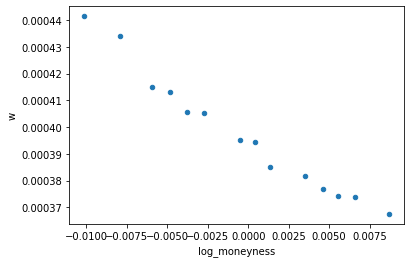

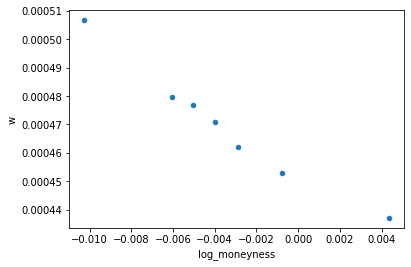

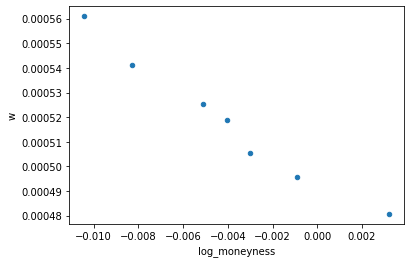

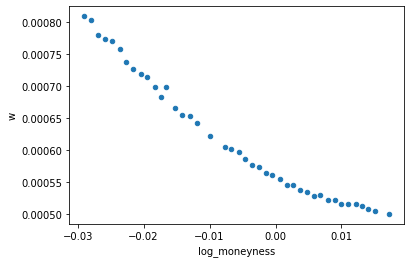

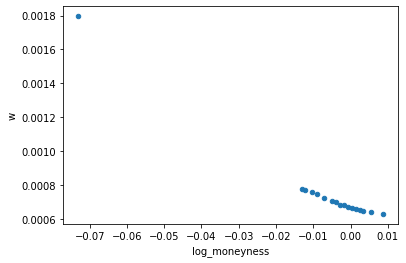

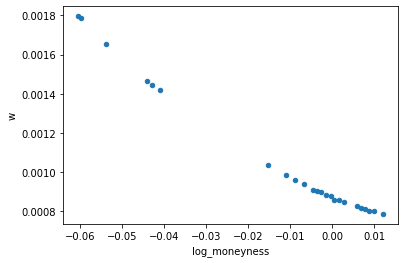

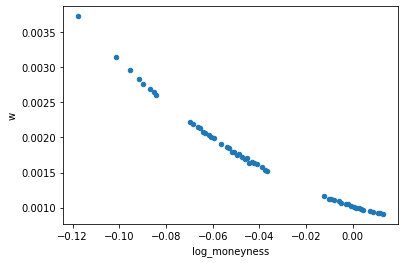

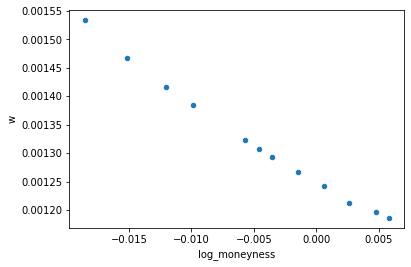

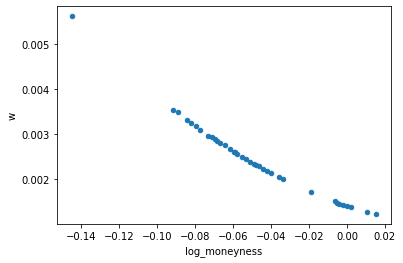

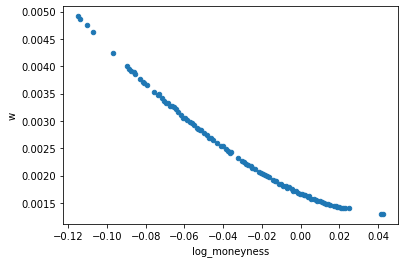

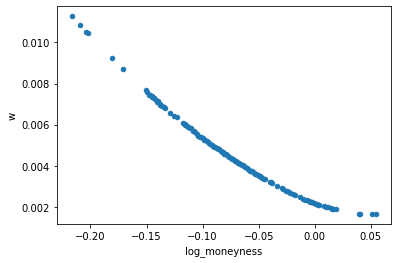

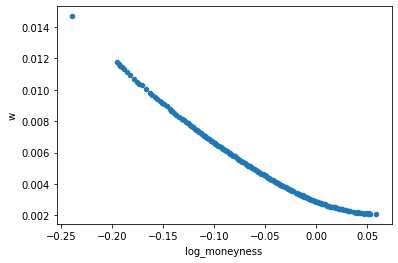

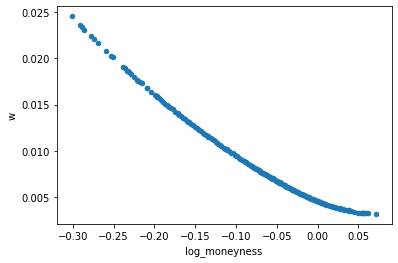

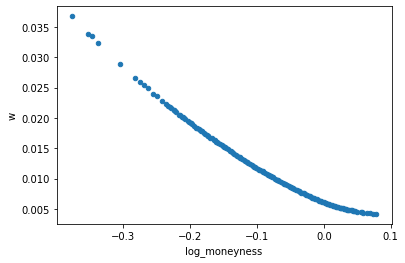

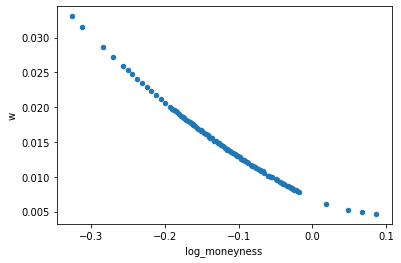

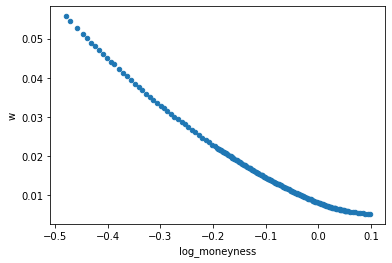

In [8]:
df_2023_12_29 = df_2023.loc["2023-12-29"]
expiries = df_2023_12_29["expire_date"].unique()

for e in expiries:
    fit = df_2023_12_29[df_2023_12_29["expire_date"]==e]
    fit["w"] = fit["T"]*fit["iv"]**2
    fit.plot(kind='scatter', x='log_moneyness', y='w')

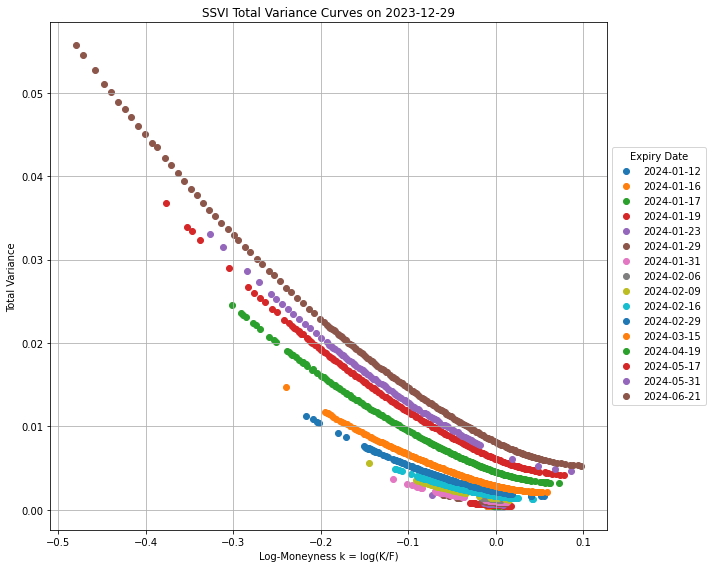

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))  # Use fig and ax for better control

for e in expiries:
    fit = df_2023_12_29[df_2023_12_29["expire_date"]==e]
    w = fit["T"]*fit["iv"]**2
    k = fit['log_moneyness']
    ax.scatter(k, w, label=str(e))
    
ax.set_xlabel("Log-Moneyness k = log(K/F)")
ax.set_ylabel("Total Variance")
ax.set_title(f"SSVI Total Variance Curves on 2023-12-29")
ax.grid(True)

# Move legend to the right
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Expiry Date")

plt.tight_layout()
plt.show()

#### BS Equations

In [10]:
def bs_implied_vol(w, T):
    return np.sqrt(w / T)

def bs_vega(S, K, sigma, r, T):
    """Calculates exact vega of an European option. Parameters are:
    - s0: Initial price of underlying stock
    - X: strike price
    - sigma: estimated implied volatility
    - r: risk-free rate in economy
    - T: time to maturity expressed in years"""
    return S*stats.norm.pdf((np.log(S/K) + (r + sigma**2/ 2)*T)/(sigma * np.sqrt(T)))*np.sqrt(T)

def black_sholes_price(S, K, r, T, sigma, call=True):
    """Calculate price of an option with BS equation for option pricing:
    - S: price today of underlying asset
    - K: strike price
    - r: annualized risk-free rate
    - T: time to maturity expressed in years
    - sigma: implied vol
    - call: optional boolen parameter, if True option in question is call, else it is treated as put"""
    d1 = (np.log(S/K) + (r + sigma**2/ 2)*T)/(sigma * np.sqrt(T))
    d2 = (np.log(S/K) + (r - sigma**2/ 2)*T)/(sigma * np.sqrt(T))
    if call==True:
        return S*stats.norm.cdf(d1) - K*np.exp(-r*T)*stats.norm.cdf(d2)
    elif call==False:
        return K*np.exp(-r*T)*stats.norm.cdf(-d2) - S*stats.norm.cdf(-d1)

In [11]:
import numpy as np
from scipy.stats import norm

def black_sholes_price_SVI(S, F, k, total_var, call):
    """
    Black-Scholes price using log-moneyness (k = log(K / F)),
    spot, forward, and total variance.
    Parameters:
    - S: Spot price
    - F: Forward price
    - log_moneyness: log(K / F)
    - T: Time to maturity
    - total_var: Total variance = sigma^2 * T
    - call: boolean array or scalar (True = call, False = put)
    
    Returns:
    - Option price
    """
    D = S / F
    sqrt_var = np.sqrt(total_var)
    d1 = (-k + 0.5 * total_var) / sqrt_var
    d2 = d1 - sqrt_var
    K = F * np.exp(k)  # recover strike from log-moneyness

    prices = np.where(
        call == True,
        D * (F * norm.cdf(d1) - K * norm.cdf(d2)),
        D * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    )
    return prices


def black_sholes_vega_SVI(S, k, sigma, T):
    """
    Black-Scholes vega in terms of:
    - S: spot price
    - k: log-moneyness (k = log(K / F))
    - sigma: implied volatility
    - T: time to maturity in years
    """
    sqrt_T = np.sqrt(T)
    d1 = (-k / (sigma * sqrt_T)) + 0.5 * sigma * sqrt_T
    vega = S * norm.pdf(d1) * sqrt_T
    return vega


#### Square-root SVI as initial guess

In [12]:
class LossTracker:
    def __init__(self, loss_fun):
        self.loss_fun = loss_fun
        self.best_loss = np.inf
        self.best_params = None

    def __call__(self, params, *args):
        loss = self.loss_fun(params, *args)
        if loss < self.best_loss:
            self.best_loss = loss
            self.best_params = params.copy()
        return loss

In [13]:
def svi_raw_to_jw(params, t):
    a, b, rho, m, sigma = params
    sqrt_term = np.sqrt(m**2 + sigma**2)
    w = a + b * (-rho * m + sqrt_term)
    v = w / t
    psi = (b / (2 *  np.sqrt(w))) * (-m / sqrt_term + rho)
    p = (b * (1 - rho)) / np.sqrt(w)
    c = (b * (1 + rho)) / np.sqrt(w)
    v_tilde = (a + b * sigma * np.sqrt(1 - rho**2)) / t
    return v, psi, p, c, v_tilde

In [14]:
def svi_jw_to_raw(params, t, tol=1e-8):
    """
    Convert SVI-JW (SSVI) parameters to raw SVI parameters.

    Inputs:
    - v: ATM implied variance
    - psi: ATM skew
    - p, c: left and right wing slopes
    - v_tilde: minimum implied variance (at m)
    - t: time to expiry
    """
    v, psi, p, c, v_tilde = params
    w = v * t  # ATM total variance

    b = np.sqrt(w) / 2 * (c + p)
    rho = 1 - p * np.sqrt(w) / b

    beta = rho - 2 * psi * np.sqrt(w) / b
    alpha = np.sign(beta) * (1 / beta**2 - 1)

    denom = b * (-rho + np.sign(alpha)*(1 + alpha**2) - alpha * (1 - rho**2))
    m = (v - v_tilde) * t / denom if abs(denom) > tol else 0.0

    if abs(m) > tol:
        sigma = alpha * m
        a = v_tilde * t - b * sigma * (1 - rho**2)
    else:
        # Since m ≈ 0, we fallback: compute 'a' first and then 'sigma'
        # Here we choose a = v_tilde * t directly (this is safe if smile minimum is at m = 0)
        a = v_tilde * t
        sigma = (v * t - a) / b

    return a, b, rho, m, sigma

In [15]:
# === Functional Forms ===
def fi_power_law_modified(theta, eta):
    return eta / ((theta**0.5) * (1 + theta)**(1 - 0.5))

def fi_power_law(theta, eta):
    return eta / (theta**0.5)

# === SSVI Total Variance Function ===
def ssvi_total_variance(theta, fi_func, k, rho, eta):
    fi_val = fi_func(theta, eta)
    w = theta / 2 * (1 + rho * fi_val * k + np.sqrt((fi_val * k + rho)**2 + (1 - rho)**2))
    return w

# === SSVI Model Price Function ===
def ssvi_price(theta, fi_func, S, F, k, T, call, rho, eta):
    w = ssvi_total_variance(theta, fi_func, k, rho, eta)
    prices = black_sholes_price_SVI(S, F, k, w, call)
    return prices

# === Loss Function for Fitting ===
def ssvi_loss(params, fi_func, group):
    rho, eta = params
    theta = group['theta_svi'].values
    S = group['underlying_last'].values
    F = group['forward'].values
    k = group['log_moneyness'].values
    T = group['T'].values 
    call = group['call'].values 
    market_prices = group['mid_price'].values
    model_prices = ssvi_price(theta, fi_func, S, F, k, T, call, rho, eta)
    return np.mean((model_prices - market_prices) ** 2)

# === Fitting Wrapper ===
def fit_ssvi_all(df, fi_func, daily_initial_guess=None, loss_func = ssvi_loss):
    fitted_params = []
    fitted_params_svi_jw = []
    fitted_raw_params = []
    epsilon = 1e-10
    grouped = df.groupby(['quote_date'])
    
    total_loss=0
    n=0

    for quote_date, group in grouped:
        if daily_initial_guess is None:
            initial_guess = [-0.5, 0.5]            
        else:
            initial_guess = daily_initial_guess.loc[quote_date[0]].values
                    
        try:
            loss_tracker = LossTracker(loss_func)
            result = minimize(
                fun=loss_tracker,
                x0=initial_guess,
                args=(fi_func, group),
                bounds=[(-1 + epsilon, 1 - epsilon), (epsilon, None)],
                #method='SLSQP',
                constraints=[{'type': 'ineq', 'fun': lambda params: 2 - params[1] * (1 + abs(params[0]))}]
            )
            rho, eta = loss_tracker.best_params
            
            loss = loss_tracker.best_loss
    
            fitted_params.append({
                'quote_date': quote_date[0],
                'rho': rho,
                'eta': eta
            })
            
            for expiry in group['expire_date'].unique():                    
                theta_i = group[group['expire_date']==expiry].iloc[0]['theta_svi']
                fi_val_i = fi_func(theta_i, eta)
                
                dte = group[group['expire_date']==expiry].iloc[0]['dte']

                a = (theta_i/2)*(1-rho**2)
                b = theta_i*fi_val_i/2
                m = -rho/fi_val_i
                sigma = np.sqrt((1 - rho)**2)/fi_val_i
                T = group['T'].values[0]
                fitted_raw_params.append({
                    'quote_date': quote_date[0],
                    'expire_date': expiry, 
                    'dte': dte,                        
                    'a': a,
                    'b': b,
                    'rho': rho,
                    'm': m,
                    'sigma': sigma   
                })
        
                v = theta_i/T
                psi = 0.5*rho*np.sqrt(theta_i)*fi_val_i
                p =  0.5*rho*np.sqrt(theta_i)*(1 - rho)
                c =  0.5*rho*np.sqrt(theta_i)*(1 + rho)
                v_tilde = v*(1-rho**2)
                
                fitted_params_svi_jw.append({
                    'quote_date': quote_date[0],
                    'expire_date': expiry,
                    'dte': dte,
                    'v': v,
                    'psi': psi,
                    'p': p,
                    'c': c,
                    'v_tilde': v_tilde
                })
                
            print(f"Fitting successfull on quote date {quote_date[0]}: Train MSE Loss {loss:.2f}")
            total_loss+=loss
            n+=1


        except Exception as e:
            print(f"Fitting failed on {quote_date[0]}: {e}")
            
    result = pd.DataFrame(fitted_params).set_index(['quote_date'])
    result_svi_jw = pd.DataFrame(fitted_params_svi_jw).set_index(['quote_date'])
    result_raw = pd.DataFrame(fitted_raw_params).set_index(['quote_date'])
    average_loss = total_loss/n
    print(f"Fitting successfull, average MSE Loss {average_loss:.2f}")
    
    return result, result_svi_jw, result_raw

In [16]:
result_ssvi, result_ssvi_jw, result_ssvi_raw = fit_ssvi_all(df_2023, fi_func=fi_power_law_modified, loss_func = ssvi_loss)

Fitting successfull on quote date 2023-01-04: Train MSE Loss 114.53
Fitting successfull on quote date 2023-01-05: Train MSE Loss 137.22
Fitting successfull on quote date 2023-01-06: Train MSE Loss 124.09
Fitting successfull on quote date 2023-01-10: Train MSE Loss 118.70
Fitting successfull on quote date 2023-01-11: Train MSE Loss 100.70
Fitting successfull on quote date 2023-01-13: Train MSE Loss 272.45
Fitting successfull on quote date 2023-01-17: Train MSE Loss 107.69
Fitting successfull on quote date 2023-01-18: Train MSE Loss 135.52
Fitting successfull on quote date 2023-01-19: Train MSE Loss 396.48
Fitting successfull on quote date 2023-01-23: Train MSE Loss 94.40
Fitting successfull on quote date 2023-01-24: Train MSE Loss 84.16
Fitting successfull on quote date 2023-01-25: Train MSE Loss 59.34
Fitting successfull on quote date 2023-01-26: Train MSE Loss 95.36
Fitting successfull on quote date 2023-01-27: Train MSE Loss 91.88
Fitting successfull on quote date 2023-01-30: Train M

Fitting successfull on quote date 2023-08-08: Train MSE Loss 333.36
Fitting successfull on quote date 2023-08-09: Train MSE Loss 137.54
Fitting successfull on quote date 2023-08-10: Train MSE Loss 129.44
Fitting successfull on quote date 2023-08-11: Train MSE Loss 73.81
Fitting successfull on quote date 2023-08-14: Train MSE Loss 106.30
Fitting successfull on quote date 2023-08-15: Train MSE Loss 148.41
Fitting successfull on quote date 2023-08-16: Train MSE Loss 63.66
Fitting successfull on quote date 2023-08-17: Train MSE Loss 137.04
Fitting successfull on quote date 2023-08-18: Train MSE Loss 163.21
Fitting successfull on quote date 2023-08-21: Train MSE Loss 319.96
Fitting successfull on quote date 2023-08-23: Train MSE Loss 96.45
Fitting successfull on quote date 2023-08-24: Train MSE Loss 274.96
Fitting successfull on quote date 2023-08-25: Train MSE Loss 102.50
Fitting successfull on quote date 2023-08-28: Train MSE Loss 88.05
Fitting successfull on quote date 2023-08-30: Train 

In [17]:
result_ssvi_raw.describe()

,dte,a,b,rho,m,sigma
count,4693.000000,4.693000e+03,4.693000e+03,4693.000000,4.693000e+03,4693.000000
mean,77.117315,2.847956e-03,4.093246e-02,-0.126778,-4.766564e+06,0.057622
std,90.001025,4.137129e-03,2.687962e-02,0.098083,6.239528e+07,0.039231
min,14.000000,1.434311e-13,1.892258e-12,-0.188424,-1.565238e+09,0.011747
25%,22.000000,5.800330e-04,2.249486e-02,-0.150792,3.466543e-03,0.029205
50%,36.000000,1.132871e-03,2.995637e-02,-0.137886,5.366133e-03,0.044832
75%,99.960000,3.369258e-03,5.242177e-02,-0.118447,8.729212e-03,0.074162
max,707.000000,4.289497e-02,1.775110e-01,1.000000,3.505044e-02,0.313018


In [18]:
result_ssvi_jw.describe()

,dte,v,psi,p,c,v_tilde
count,4693.000000,4693.000000,4.693000e+03,4.693000e+03,4693.000000,4.693000e+03
mean,77.117315,0.148856,-8.705106e-02,-4.810220e-03,-0.003172,1.452528e-01
std,90.001025,0.215454,2.084586e-02,3.117593e-03,0.006890,2.120998e-01
min,14.000000,0.007721,-1.415160e-01,-2.448688e-02,-0.018023,7.478906e-12
25%,22.000000,0.030859,-1.002860e-01,-6.290527e-03,-0.004801,2.952287e-02
50%,36.000000,0.059787,-8.611106e-02,-3.799183e-03,-0.002844,5.772566e-02
75%,99.960000,0.175521,-7.379401e-02,-2.639667e-03,-0.002012,1.700365e-01
max,707.000000,2.265322,4.996418e-11,7.734209e-12,0.154684,2.236666e+00


In [19]:
result_ssvi.describe()

,rho,eta
count,215.000000,2.150000e+02
mean,-0.125284,1.299948e+00
std,0.112293,2.123523e-01
min,-0.188424,1.000000e-10
25%,-0.152088,1.195867e+00
50%,-0.139659,1.316464e+00
75%,-0.119388,1.430853e+00
max,1.000000,1.834771e+00


### Try loss with total variance function

In [20]:
# === Loss Function for Fitting ===
def ssvi_loss_w(params, fi_func, group):
    rho, eta = params
    scale = 10e4
    theta = group['theta_svi'].values
    k = group['log_moneyness'].values
    market_w = group['w'].values 
    model_w = ssvi_total_variance(theta, fi_func, k, rho, eta)
    return scale*np.mean((model_w - market_w) ** 2)

In [21]:
result_ssvi_variance, result_ssvi_jw_variance, result_ssvi_raw_variance = fit_ssvi_all(df_2023, fi_func=fi_power_law_modified, loss_func = ssvi_loss_w)

Fitting successfull on quote date 2023-01-04: Train MSE Loss 0.29
Fitting successfull on quote date 2023-01-05: Train MSE Loss 0.65
Fitting successfull on quote date 2023-01-06: Train MSE Loss 0.26
Fitting successfull on quote date 2023-01-10: Train MSE Loss 0.47
Fitting successfull on quote date 2023-01-11: Train MSE Loss 0.36
Fitting successfull on quote date 2023-01-13: Train MSE Loss 1.69
Fitting successfull on quote date 2023-01-17: Train MSE Loss 0.32
Fitting successfull on quote date 2023-01-18: Train MSE Loss 0.43
Fitting successfull on quote date 2023-01-19: Train MSE Loss 2.80
Fitting successfull on quote date 2023-01-23: Train MSE Loss 0.26
Fitting successfull on quote date 2023-01-24: Train MSE Loss 0.19
Fitting successfull on quote date 2023-01-25: Train MSE Loss 0.12
Fitting successfull on quote date 2023-01-26: Train MSE Loss 0.24
Fitting successfull on quote date 2023-01-27: Train MSE Loss 0.22
Fitting successfull on quote date 2023-01-30: Train MSE Loss 0.31
Fitting su

Fitting successfull on quote date 2023-08-10: Train MSE Loss 0.17
Fitting successfull on quote date 2023-08-11: Train MSE Loss 0.07
Fitting successfull on quote date 2023-08-14: Train MSE Loss 0.16
Fitting successfull on quote date 2023-08-15: Train MSE Loss 0.24
Fitting successfull on quote date 2023-08-16: Train MSE Loss 0.06
Fitting successfull on quote date 2023-08-17: Train MSE Loss 0.31
Fitting successfull on quote date 2023-08-18: Train MSE Loss 0.32
Fitting successfull on quote date 2023-08-21: Train MSE Loss 1.71
Fitting successfull on quote date 2023-08-23: Train MSE Loss 0.13
Fitting successfull on quote date 2023-08-24: Train MSE Loss 0.85
Fitting successfull on quote date 2023-08-25: Train MSE Loss 0.14
Fitting successfull on quote date 2023-08-28: Train MSE Loss 0.10
Fitting successfull on quote date 2023-08-30: Train MSE Loss 0.12
Fitting successfull on quote date 2023-08-31: Train MSE Loss 0.13
Fitting successfull on quote date 2023-09-01: Train MSE Loss 0.09
Fitting su

### Calendar Arbitrage Plot

In [22]:
## Define your function to compute raw SVI total variance
#def svi_raw_total_variance(k, a, b, rho, m, sigma):
#    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

# === SSVI Total Variance Function ===
def svi_raw_total_variance(params, k):
    a, b, rho, m , sigma = params
    w = a + b*(rho*(k-m) + np.sqrt((k-m)**2 + sigma**2))
    return w

# Plotting function
def plot_svi_curves(date, data, raw_params, k_min=-0.5, k_max=0.5, k_step=0.01, figsize=(10, 8)):
    day = raw_params.loc[date]
    expiries = day["expire_date"].unique()
    k_range = np.arange(k_min, k_max + k_step, k_step)

    fig, ax = plt.subplots(figsize=figsize)  # Use fig and ax for better control
    
    for expiry in expiries:
        params = day[day["expire_date"] == expiry].iloc[0]  # assuming one row per expiry
        w = svi_raw_total_variance(params[["a", "b", "rho", "m", "sigma"]], k_range)
        ax.plot(k_range, w, label=str(expiry))
        fit = data[(data["expire_date"]==expiry) & (data.index == date)]
        w = fit["T"]*fit["iv"]**2
        k = fit['log_moneyness']
        ax.scatter(k, w, label=str(expiry))

    ax.set_xlabel("Log-Moneyness k = log(K/F)")
    ax.set_ylabel("Total Variance")
    ax.set_title(f"SSVI Total Variance Curves on {date}")
    ax.grid(True)

    # Move legend to the right
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Expiry Date")

    plt.tight_layout()
    plt.show()

In [23]:
dates = result_ssvi.index.unique()
dates

Index(['2023-01-04', '2023-01-05', '2023-01-06', '2023-01-10', '2023-01-11',
       '2023-01-13', '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-23',
       ...
       '2023-12-14', '2023-12-15', '2023-12-18', '2023-12-19', '2023-12-20',
       '2023-12-21', '2023-12-22', '2023-12-26', '2023-12-28', '2023-12-29'],
      dtype='object', name='quote_date', length=215)

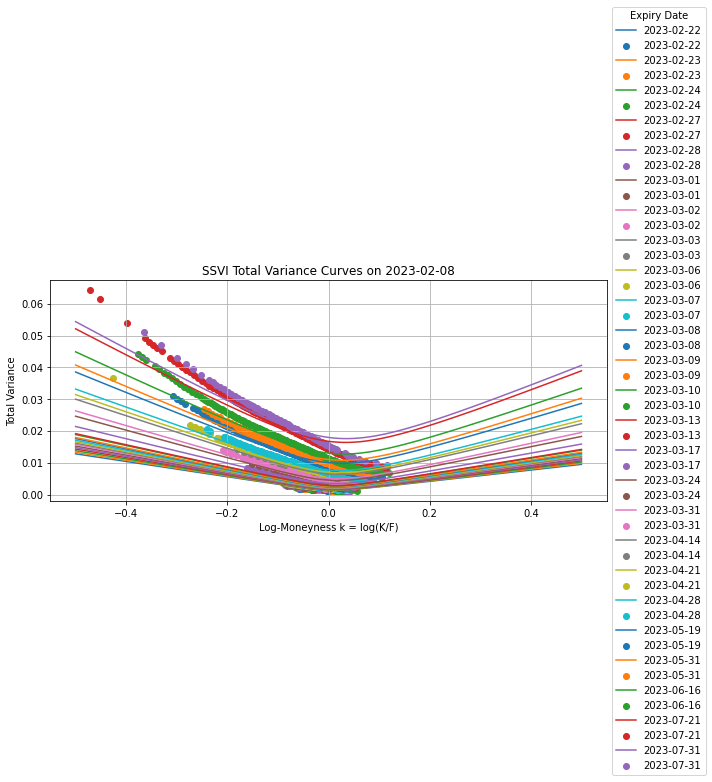

In [24]:
plot_svi_curves(dates[20], df_2023, result_ssvi_raw)

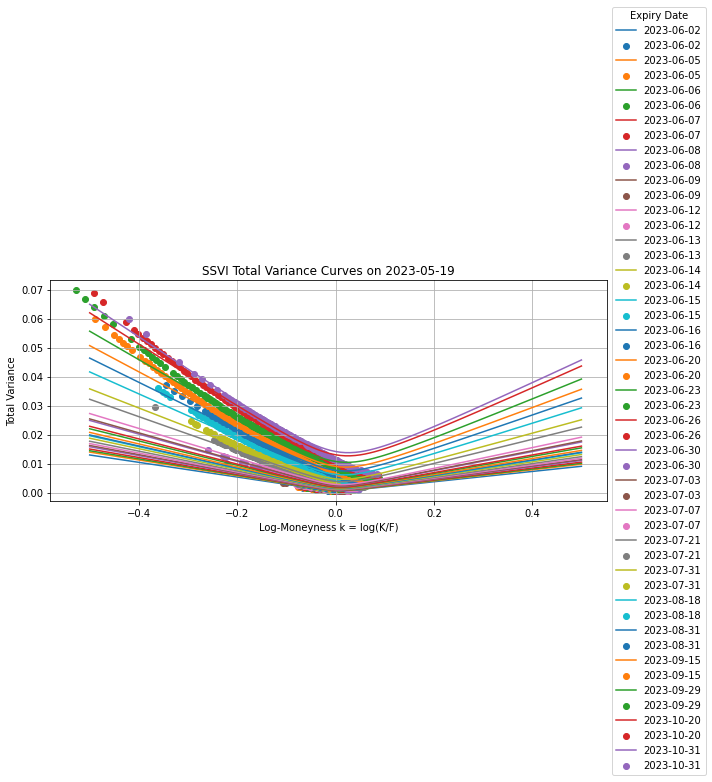

In [25]:
plot_svi_curves(dates[75], df_2023, result_ssvi_raw_variance)

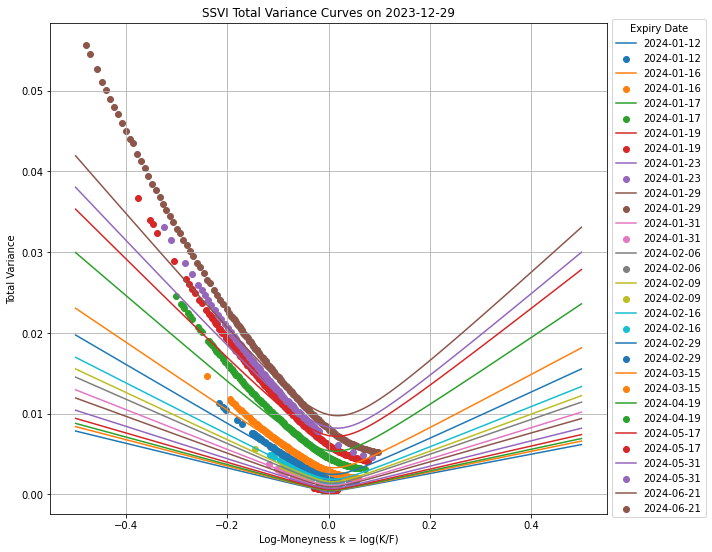

In [26]:
plot_svi_curves(dates[-1], df_2023, result_ssvi_raw)

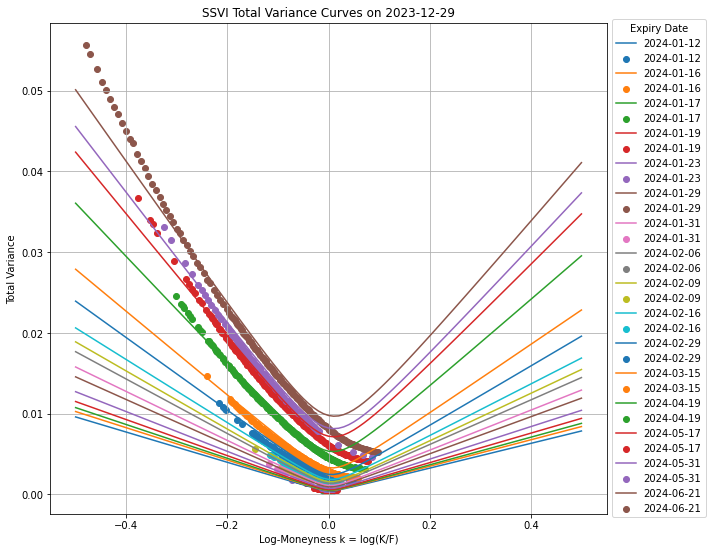

In [27]:
plot_svi_curves(dates[-1], df_2023, result_ssvi_raw_variance)

### Fit SVI slice by slice

In [28]:
def curve_intersection(curve1, curve2):
    a1_val, b1_val, rho1_val, m1_val, sigma1_val = curve1
    a2_val, b2_val, rho2_val, m2_val, sigma2_val = curve2
    
    k, b1, b2, m1, m2, sigma1, sigma2, alpha, beta = symbols('k b1 b2 m1 m2 sigma1 sigma2 alpha beta')
    
    lhs_inner = 2 * b2 * (alpha + beta * k) * ((k - m2)**2 + sigma2**2)**Rational(1, 2)
    lhs_expr = expand(simplify(lhs_inner))
    
    rhs_inner = b1**2 * ((k - m1)**2 + sigma1**2) - b2**2 * ((k - m2)**2 + sigma2**2) - (alpha + beta * k)**2
    rhs_expr = expand(simplify(rhs_inner))
    # Subtract: LHS - RHS
    diff_expr = expand(simplify(lhs_expr - rhs_expr))
    
    values = {
    b1: b1_val,
    b2: b2_val,
    m1: m1_val,
    m2: m2_val,
    sigma1: sigma1_val,
    sigma2: sigma2_val,
    alpha: a2_val - a1_val + b1_val*rho1_val*m1_val - b2_val*rho2_val*m2_val,
    beta: b2_val*rho2_val - b1_val*rho1_val,
    }
    
    expr_substituted = diff_expr.subs(values)
    roots = solve(expr_substituted, k)
    return roots
    
def crossedness(curve1, curve2): # curve1 corresponds to t1, curve2 to t2 and t2>t1
    if (curve1 is None) or (curve2 is None):
        return 0
    else:
        roots = curve_intersection(curve1, curve2)
        
        real_roots = []
        for root in roots:
            val = root.evalf()
            real_part, imag_part = val.as_real_imag()
            if abs(imag_part) < 1e-10:
                real_roots.append(float(real_part))
       
        real_roots.sort() # increasing order 
        
        if len(real_roots)>0:
            #print(f"Roots are {roots}")
            #print(f"Real roots are {real_roots}")

            k_tilde = []

            for i in range(len(real_roots)+1): # 0, 1, 2, 3, 4
                if i==0:
                    k_tilde.append(real_roots[i]-1)
                elif (i>=1) and (i<=len(real_roots)-1):
                    k_tilde.append((real_roots[i]+real_roots[i-1])/2)
                else:
                    k_tilde.append(real_roots[i-1]+1)
            
            ci = [max(0, svi_raw_total_variance(curve1, k)-svi_raw_total_variance(curve2, k)) for k in k_tilde]
            #print(ci)
        else:
            ci=[0]
        return max(ci)

In [29]:
def vega_weights(params, S, k, T):
    w = svi_raw_total_variance(params, k) 
    bs_sigma = bs_implied_vol(w, T)
    vega = black_sholes_vega_SVI(S, k, bs_sigma, T)
    weights = vega / (np.sum(vega) + 1e-6)
    return weights

def equal_weights(params, S, k, T):
    return np.ones_like(k) / len(k)

def inverse_vega_weights(params, S, k, T):
    w = svi_raw_total_variance(params, k)
    bs_sigma = bs_implied_vol(w, T)
    vega = black_sholes_vega_SVI(S, k, bs_sigma, T)
    inv_vega = 1.0 / (vega + 1e-6)
    return inv_vega / np.sum(inv_vega)

def wing_weights(params, S, k, T):
    gamma = 2
    # Quadratic emphasis on wings
    weights = 1 + gamma * (np.abs(k) ** 2)
    # Normalize
    weights /= np.mean(weights)
    return weights

In [30]:
def svi_raw_prices(params, S, F, k, call):
    w = svi_raw_total_variance(params, k)  
    prices = black_sholes_price_SVI(S, F, k, w, call)
    return prices

def svi_slice_loss(params, slice_data, prev_slice_params, next_slice_params, penalty_weight, crossedness_fun, weighting):
    S = slice_data['underlying_last'].values[0]
    F = slice_data['forward'].values
    k = slice_data['log_moneyness'].values
    T = slice_data['T'].values[0]
    market_prices = slice_data['mid_price'].values
    call = slice_data['call'].values
    
    model_prices = svi_raw_prices(params, S, F, k, call)
    
    if (
        np.any(np.isnan(model_prices)) or
        np.any(np.isinf(model_prices)) or
        np.any(model_prices < 0)
    ):
        return penalty_weight  # invalid model output
    
    se = (model_prices - market_prices)**2
    weights =  weighting(params, S, k, T)
    mse = np.sum(se*weights)
    c1 = crossedness_fun(prev_slice_params, params)
    c2 = crossedness_fun(params, next_slice_params) 
    penaltyC = c1 + c2  

    loss = mse + penalty_weight * penaltyC
    return loss

# === Fitting Wrapper ===
def fit_svi_slice_by_slice(df, daily_initial_guess, daily_next_guess, penalty_weight, bounds, strict_bounds, constraints, crossedness_fun=crossedness, weighting=equal_weights, loss_func=svi_slice_loss):    
    fitted_params_raw = []
    fitted_params_svi_jw = []
    grouped = df.groupby(['quote_date'])
    
    for (quote_date,), group in grouped:
                
        total_loss = 0
        n_day = len(group)
        
        slices = group.groupby(['expire_date'])        
        prev_slice_params =  None
        
        for (expire_date, ), slice_data in slices:
                        
            n_slice = len(slice_data)
            
            initial_guess = daily_initial_guess.loc[(quote_date, expire_date)].values
            
            next_slice_params = daily_next_guess.loc[(quote_date, expire_date)].values
            if None in next_slice_params:
                next_slice_params = None
                
            print(f"Processing {quote_date}, expire date {expire_date}.") 
            try:
                loss_tracker1 = LossTracker(loss_func)
                result = minimize(
                    fun=loss_tracker1,
                    x0=initial_guess,
                    args=(slice_data, prev_slice_params, next_slice_params, penalty_weight, crossedness_fun, weighting),
                    bounds=bounds,
                    constraints= constraints,
                    method='SLSQP',
                    options={'maxiter': 500, 'verbose': 3}
                    )
            
                loss_tracker2 = LossTracker(loss_func)

                result = minimize(
                     fun=loss_tracker2,
                     x0=initial_guess,
                     args=(slice_data, prev_slice_params, next_slice_params, penalty_weight, crossedness_fun, weighting),
                     bounds=strict_bounds,
                     constraints= constraints,
                     method='SLSQP',
                     options={'maxiter': 500, 'verbose': 3}
                     )
                
                dte = slice_data['dte'].values[0]
                T = dte/365
                    
                if loss_tracker1.best_loss < loss_tracker2.best_loss:
                    loss_tracker = loss_tracker1
                else:
                    loss_tracker = loss_tracker2
                    
                a, b, rho, m , sigma = loss_tracker.best_params
                v, psi, p, c, v_tilde = svi_raw_to_jw(loss_tracker.best_params, T)
                prev_slice_params = loss_tracker.best_params
                loss = loss_tracker.best_loss
                            
                fitted_params_raw.append({
                    'quote_date': quote_date,
                    'expire_date': expire_date,
                    'dte': dte,
                    'a': a,
                    'b': b,
                    'rho': rho,
                    'm': m,
                    'sigma': sigma
                })

                fitted_params_svi_jw.append({
                    'quote_date': quote_date,
                    'expire_date': expire_date,
                    'dte': dte,
                    'v': v,
                    'psi': psi,
                    'p': p,
                    'c': c,
                    'v_tilde': v_tilde
                })
                
                total_loss += loss*n_slice
                print(f"Fitting successfull on quote date {quote_date}, expire date {expire_date}: Train MSE Loss {loss:.2f}")
                print(f"Params are a,b, rho, m sigma = {a:.4f}, {b:.4f}, {rho:.4f}, {m:.4f} , {sigma:.4f}")
                print(f"Params are v,psi, p, c v_tilde = {v:.4f}, {psi:.4f}, {p:.4f}, {c:.4f} , {v_tilde:.4f}")
      
            except Exception as e:
                print(f"Fitting failed on quote date {quote_date}, expire date {expire_date}: {e}")
                
        total_loss = total_loss/n_day                
        print(f"Fitting successfull on quote date {quote_date}: Train MSE Loss {total_loss:.2f}")

    result_raw = pd.DataFrame(fitted_params_raw).set_index(['quote_date'])
    result_svi_jw = pd.DataFrame(fitted_params_svi_jw).set_index(['quote_date'])
   
    return result_raw, result_svi_jw

def raw_convexity_constraint(params):
    a, b, rho, m, sigma = params
    val = a + b * sigma * np.sqrt(1 - rho**2)
    if np.isnan(val) or np.isinf(val):
        return -1e10  # return negative value to indicate violation
    return val

### Minimizing price loss - 2023-12-29

In [31]:
df_2023_12_29 = df_2023.loc["2023-12-29"]

next_guess = result_ssvi_raw.groupby("quote_date").apply(lambda x: x.shift(-1)).reset_index(level=0,drop=True).replace({np.nan: None})
next_guess["expire_date"] = result_ssvi_raw["expire_date"]

daily_initial_guess_2023_12_29 = result_ssvi_raw.loc["2023-12-29"].reset_index().set_index(["quote_date","expire_date"]).drop(columns=["dte"])
daily_next_guess_2023_12_29 = next_guess.loc["2023-12-29"].reset_index().set_index(["quote_date","expire_date"]).drop(columns=["dte"])

#### Equal Weights

In [32]:
epsilon = 1e-6 
penalty_weight = 1e10

bounds = Bounds(
    [-1,    epsilon,     -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  np.inf]   # Upper bounds
    )

strict_bounds = Bounds(
    [-1,    epsilon,  -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  10]   # Upper bounds
      )

constraints = [
    NonlinearConstraint(raw_convexity_constraint, 0, np.inf)
    ]

result_slice_raw, result_slice_jw = fit_svi_slice_by_slice(df_2023_12_29, daily_initial_guess_2023_12_29, daily_next_guess_2023_12_29, penalty_weight, bounds, strict_bounds, constraints, crossedness_fun=crossedness, weighting=equal_weights)

Processing 2023-12-29, expire date 2024-01-12.
Fitting successfull on quote date 2023-12-29, expire date 2024-01-12: Train MSE Loss 1.55
Params are a,b, rho, m sigma = -0.0003, 0.0136, -0.1197, -0.0022 , 0.0559
Params are v,psi, p, c v_tilde = 0.0108, -0.0268, 0.7468, 0.5871 , 0.0108
Processing 2023-12-29, expire date 2024-01-16.
Fitting successfull on quote date 2023-12-29, expire date 2024-01-16: Train MSE Loss 1.10
Params are a,b, rho, m sigma = 0.0002, 0.0147, -0.0945, 0.0003 , 0.0186
Params are v,psi, p, c v_tilde = 0.0097, -0.0381, 0.7387, 0.6112 , 0.0096
Processing 2023-12-29, expire date 2024-01-17.
Fitting successfull on quote date 2023-12-29, expire date 2024-01-17: Train MSE Loss 1.71
Params are a,b, rho, m sigma = 0.0002, 0.0162, -0.1194, -0.0015 , 0.0189
Params are v,psi, p, c v_tilde = 0.0102, -0.0146, 0.7882, 0.6201 , 0.0102
Processing 2023-12-29, expire date 2024-01-19.
Fitting successfull on quote date 2023-12-29, expire date 2024-01-19: Train MSE Loss 6.96
Params are 

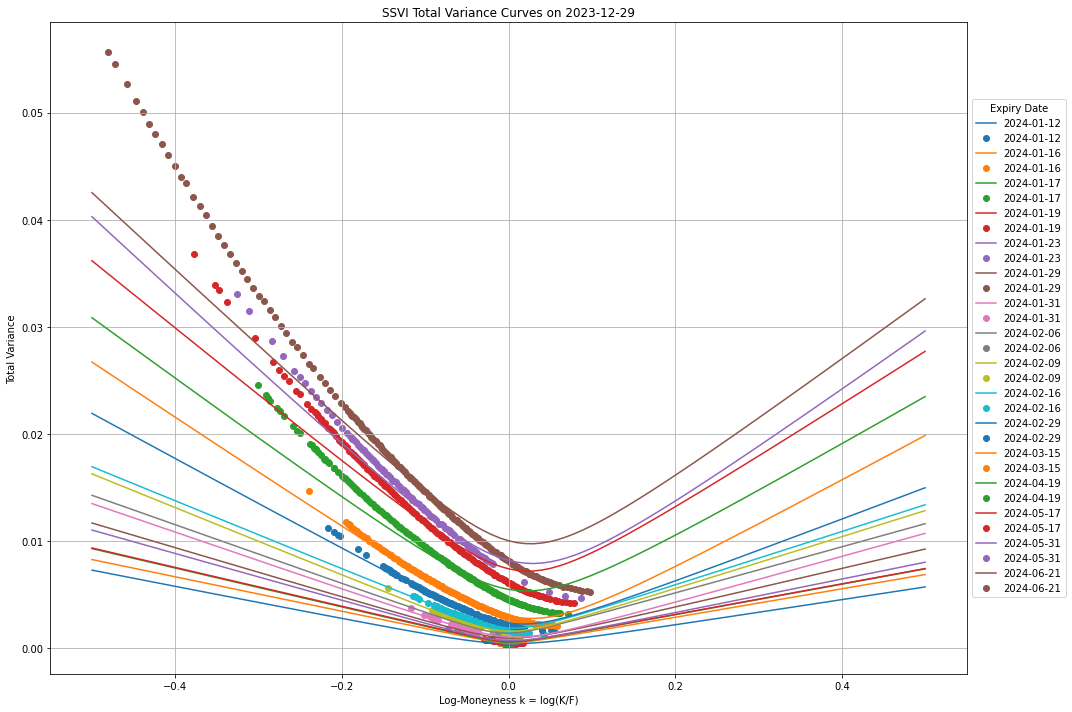

In [34]:
result_slice_raw.to_csv("results/Raw-slice-by-slice.csv")
result_2023_12_29= pd.read_csv("results/Raw-slice-by-slice.csv", header = 0).set_index(["quote_date"])
plot_svi_curves("2023-12-29", df_2023, result_2023_12_29,  figsize=(15, 10))

#### Vega Weights

In [35]:
epsilon = 1e-6 
penalty_weight = 1e10

bounds = Bounds(
    [-1,    epsilon,     -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  np.inf]   # Upper bounds
    )

strict_bounds = Bounds(
    [-1,    epsilon,  -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  10]   # Upper bounds
      )

constraints = [
    NonlinearConstraint(raw_convexity_constraint, 0, np.inf)
    ]

result_slice_raw_vega, result_slice_jw_vega = fit_svi_slice_by_slice(df_2023_12_29, daily_initial_guess_2023_12_29, daily_next_guess_2023_12_29, penalty_weight, bounds, strict_bounds, constraints, crossedness_fun=crossedness, weighting=vega_weights)

Processing 2023-12-29, expire date 2024-01-12.
Fitting successfull on quote date 2023-12-29, expire date 2024-01-12: Train MSE Loss 4.34
Params are a,b, rho, m sigma = 0.0002, 0.0136, -0.1194, 0.0018 , 0.0167
Params are v,psi, p, c v_tilde = 0.0112, -0.0739, 0.7341, 0.5775 , 0.0111
Processing 2023-12-29, expire date 2024-01-16.
Fitting successfull on quote date 2023-12-29, expire date 2024-01-16: Train MSE Loss 1.78
Params are a,b, rho, m sigma = 0.0002, 0.0152, -0.1183, -0.0004 , 0.0189
Params are v,psi, p, c v_tilde = 0.0098, -0.0332, 0.7711, 0.6079 , 0.0098
Processing 2023-12-29, expire date 2024-01-17.
Fitting successfull on quote date 2023-12-29, expire date 2024-01-17: Train MSE Loss 0.27
Params are a,b, rho, m sigma = 0.0002, 0.0159, -0.1178, 0.0008 , 0.0209
Params are v,psi, p, c v_tilde = 0.0097, -0.0554, 0.7880, 0.6219 , 0.0097
Processing 2023-12-29, expire date 2024-01-19.
Fitting successfull on quote date 2023-12-29, expire date 2024-01-19: Train MSE Loss 1.19
Params are a,

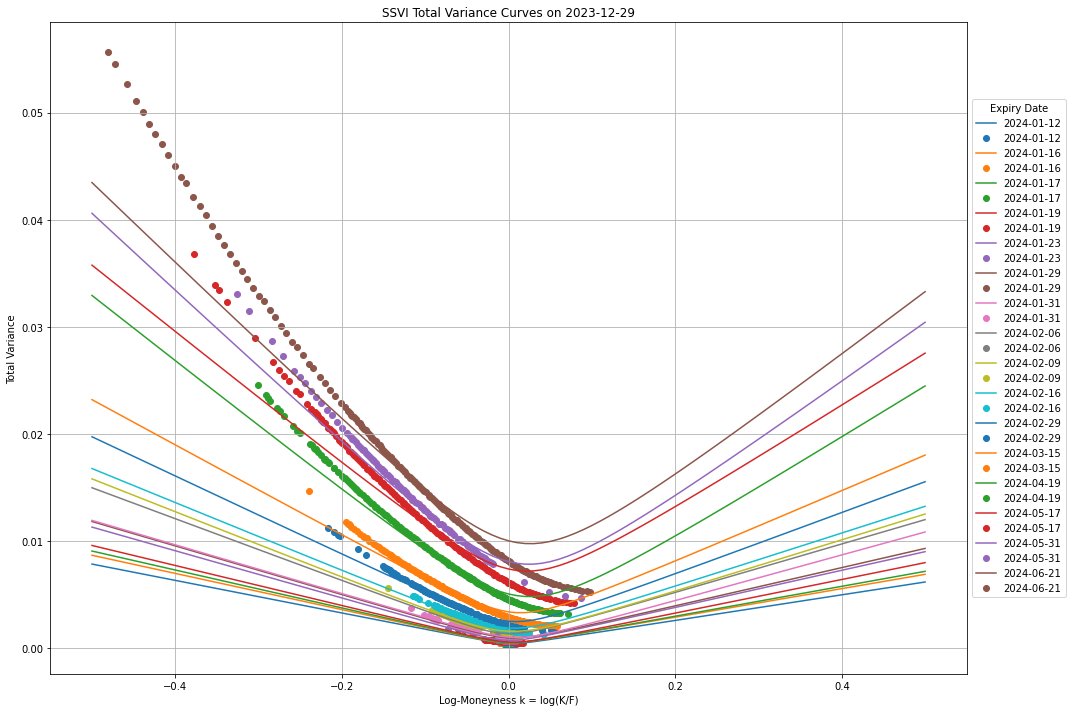

In [36]:
result_slice_raw_vega.to_csv("results/Raw-slice-by-slice-VegaW.csv")
result_2023_12_29_vegaW = pd.read_csv("results/Raw-slice-by-slice-VegaW.csv" , header = 0).set_index(["quote_date"])
plot_svi_curves("2023-12-29", df_2023, result_2023_12_29_vegaW,  figsize=(15, 10))

#### Inverse Vega Weights

In [ ]:
epsilon = 1e-6 
penalty_weight = 1e10

bounds = Bounds(
    [-1,    epsilon,     -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  np.inf]   # Upper bounds
    )

strict_bounds = Bounds(
    [-1,    epsilon,  -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  10]   # Upper bounds
      )

constraints = [
    NonlinearConstraint(raw_convexity_constraint, 0, np.inf)
    ]

result_slice_raw, result_slice_jw = fit_svi_slice_by_slice(df_2023_12_29, daily_initial_guess_2023_12_29, daily_next_guess_2023_12_29, penalty_weight, bounds, strict_bounds, constraints, crossedness_fun=crossedness, weighting=inverse_vega_weights)

Processing 2023-12-29, expire date 2024-01-12.
Fitting successfull on quote date 2023-12-29, expire date 2024-01-12: Train MSE Loss 0.02
Params are a,b, rho, m sigma = -0.0002, 0.0143, -0.1201, 0.0056 , 0.0406
Params are v,psi, p, c v_tilde = 0.0102, -0.0929, 0.8079, 0.6346 , 0.0097
Processing 2023-12-29, expire date 2024-01-16.
Fitting successfull on quote date 2023-12-29, expire date 2024-01-16: Train MSE Loss 0.08
Params are a,b, rho, m sigma = 0.0000, 0.0147, -0.0972, 0.0014 , 0.0274
Params are v,psi, p, c v_tilde = 0.0093, -0.0505, 0.7569, 0.6227 , 0.0092
Processing 2023-12-29, expire date 2024-01-17.
Fitting successfull on quote date 2023-12-29, expire date 2024-01-17: Train MSE Loss 0.04
Params are a,b, rho, m sigma = 0.0000, 0.0156, -0.1173, 0.0030 , 0.0301
Params are v,psi, p, c v_tilde = 0.0096, -0.0757, 0.7793, 0.6157 , 0.0093
Processing 2023-12-29, expire date 2024-01-19.
Fitting successfull on quote date 2023-12-29, expire date 2024-01-19: Train MSE Loss 2.38
Params are a,

In [ ]:
result_slice_raw.to_csv("results/Raw-slice-by-slice-InVegaW.csv")
result_2023_12_29_InVegaW = pd.read_csv("results/Raw-slice-by-slice-InVegaW.csv" , header = 0).set_index(["quote_date"])
plot_svi_curves("2023-12-29", df_2023, result_2023_12_29_InVegaW,  figsize=(15, 10))

### Minimizing total variance loss - 2023-12-29

In [ ]:
def svi_slice_loss_w(params, slice_data, prev_slice_params, next_slice_params, penalty_weight, crossedness_fun, weighting):
    scale=10e4
    k = slice_data['log_moneyness'].values
    T = slice_data['T'].values 
    S = slice_data['underlying_last'].values
    market_w = slice_data['w'].values*100
    model_w = svi_raw_total_variance(params, k)*100
    if (
        np.any(np.isnan(model_w)) or
        np.any(np.isinf(model_w)) or
        np.any(model_w < 0)
    ):
        return penalty_weight  # invalid model output
    se = scale*(model_w - market_w)**2
    weights = weighting(params, S, k, T)
    mse = np.sum(se*weights)
    c1 = crossedness_fun(prev_slice_params, params)
    c2 = crossedness_fun(params, next_slice_params) 
    penaltyC = c1 + c2  
    penaltyM = 0

    loss = mse + penalty_weight * penaltyC + penalty_weight * penaltyM
    return loss

In [ ]:
df_2023_12_29 = df_2023.loc["2023-12-29"]

next_guess_variance = result_ssvi_raw_variance.groupby("quote_date").apply(lambda x: x.shift(-1)).reset_index(level=0,drop=True).replace({np.nan: None})
next_guess_variance["expire_date"] = result_ssvi_raw_variance["expire_date"]

daily_initial_guess_2023_12_29_variance = result_ssvi_raw_variance.loc["2023-12-29"].reset_index().set_index(["quote_date","expire_date"]).drop(columns=["dte"])
daily_next_guess_2023_12_29_variance = next_guess_variance.loc["2023-12-29"].reset_index().set_index(["quote_date","expire_date"]).drop(columns=["dte"])

In [ ]:
epsilon = 1e-6 
penalty_weight = 1e10

bounds = Bounds(
    [-1,    epsilon,     -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  np.inf]   # Upper bounds
    )

strict_bounds = Bounds(
    [-1,    epsilon,  -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  10]   # Upper bounds
      )

constraints = [
    NonlinearConstraint(raw_convexity_constraint, 0, np.inf)
    ]

result_slice_raw_variance, result_slice_jw_variance = fit_svi_slice_by_slice(df_2023_12_29, daily_initial_guess_2023_12_29_variance, daily_next_guess_2023_12_29_variance, penalty_weight, bounds, strict_bounds, constraints, crossedness_fun=crossedness, weighting=equal_weights, loss_func=svi_slice_loss_w)

In [ ]:
result_slice_raw_variance.to_csv("results/Raw-slice-by-slice_VarianceLoss.csv")
result_2023_12_29_variance= pd.read_csv("results/Raw-slice-by-slice_VarianceLoss.csv", header = 0).set_index(["quote_date"])
plot_svi_curves("2023-12-29", df_2023, result_2023_12_29_variance,  figsize=(15, 10))

### Minimizing price loss - 2023-12-28

In [ ]:
df_2023_12_28 = df_2023.loc["2023-12-28"]
expiries = df_2023_12_28["expire_date"].unique()

for e in expiries:
    fit = df_2023_12_28[df_2023_12_28["expire_date"]==e]
    fit["w"] = fit["T"]*fit["iv"]**2
    fit.plot(kind='scatter', x='log_moneyness', y='w')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))  # Use fig and ax for better control
expiries = df_2023_12_28["expire_date"].unique()
for e in expiries:
    fit = df_2023_12_28[df_2023_12_28["expire_date"]==e]
    w = fit["T"]*fit["iv"]**2
    k = fit['log_moneyness']
    ax.scatter(k, w, label=str(e))
    
ax.set_xlabel("Log-Moneyness k = log(K/F)")
ax.set_ylabel("Total Variance")
ax.set_title(f"SSVI Total Variance Curves on 2023-12-28")
ax.grid(True)

# Move legend to the right
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Expiry Date")

plt.tight_layout()
plt.show()

In [ ]:
next_guess = result_ssvi_raw.groupby("quote_date").apply(lambda x: x.shift(-1)).reset_index(level=0,drop=True).replace({np.nan: None})
next_guess["expire_date"] = result_ssvi_raw["expire_date"]

df_2023_12_28 = df_2023.loc["2023-12-28"]
daily_initial_guess_2023_12_28 = result_ssvi_raw.loc["2023-12-28"].reset_index().set_index(["quote_date","expire_date"]).drop(columns=["dte"])
daily_next_guess_2023_12_28 = next_guess.loc["2023-12-28"].reset_index().set_index(["quote_date","expire_date"]).drop(columns=["dte"])

In [ ]:
epsilon = 1e-6 
penalty_weight = 1e10

bounds = Bounds(
    [-1,    epsilon,     -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  np.inf]   # Upper bounds
    )

strict_bounds = Bounds(
    [-1,    epsilon,  -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  10]   # Upper bounds
      )

constraints = [
    NonlinearConstraint(raw_convexity_constraint, 0, np.inf)
    ]

result_slice_raw, result_slice_jw = fit_svi_slice_by_slice(df_2023_12_28, daily_initial_guess_2023_12_28, daily_next_guess_2023_12_28, penalty_weight, bounds, strict_bounds, constraints, crossedness_fun=crossedness, weighting=equal_weights)

In [ ]:
result_slice_raw.to_csv("Raw-slice-by-slice_2023-12-28.csv")

In [ ]:
result_2023_12_28 = pd.read_csv("Raw-slice-by-slice_2023-12-28.csv", header = 0).set_index(["quote_date"])
plot_svi_curves("2023-12-28", df_2023, result_2023_12_28,  figsize=(15, 10))

In [ ]:
epsilon = 1e-6 
penalty_weight = 1e10

bounds = Bounds(
    [-1,    epsilon,     -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  np.inf]   # Upper bounds
    )

strict_bounds = Bounds(
    [-1,    epsilon,  -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  10]   # Upper bounds
      )

constraints = [
    NonlinearConstraint(raw_convexity_constraint, 0, np.inf)
    ]

result_slice_raw, result_slice_jw = fit_svi_slice_by_slice(df_2023_12_28, daily_initial_guess_2023_12_28, daily_next_guess_2023_12_28, penalty_weight, bounds, strict_bounds, constraints, crossedness_fun=crossedness, weighting=vega_weights)

In [ ]:
result_slice_raw.to_csv("Raw-slice-by-slice-VegaW_2023-12-28.csv")

In [ ]:
result_vegaW_2023_12_28 = pd.read_csv("Raw-slice-by-slice-VegaW_2023-12-28.csv", header = 0).set_index(["quote_date"])
plot_svi_curves("2023-12-28", df_2023, result_vegaW_2023_12_28,  figsize=(15, 10))

In [ ]:
epsilon = 1e-6 
penalty_weight = 1e10

bounds = Bounds(
    [-1,    epsilon,     -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  np.inf]   # Upper bounds
    )

strict_bounds = Bounds(
    [-1,    epsilon,  -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  10]   # Upper bounds
      )

constraints = [
    NonlinearConstraint(raw_convexity_constraint, 0, np.inf)
    ]

result_slice_raw, result_slice_jw = fit_svi_slice_by_slice(df_2023_12_28, daily_initial_guess_2023_12_28, daily_next_guess_2023_12_28, penalty_weight, bounds, strict_bounds, constraints, crossedness_fun=crossedness, weighting=inverse_vega_weights)

In [ ]:
result_slice_raw.to_csv("Raw-slice-by-slice-InvVegaW_2023-12-28.csv")

In [ ]:
result_2023_12_28_vegaW = pd.read_csv("Raw-slice-by-slice-InvVegaW_2023-12-28.csv", header = 0).set_index(["quote_date"])
plot_svi_curves("2023-12-28", df_2023, result_2023_12_28_vegaW,  figsize=(15, 10))

### Minimizing price loss - 2023-11-17

In [ ]:
df_2023_11_17 = df_2023.loc["2023-11-17"]
expiries = df_2023_11_17["expire_date"].unique()

for e in expiries:
    fit = df_2023_11_17[df_2023_11_17["expire_date"]==e]
    fit["w"] = fit["T"]*fit["iv"]**2
    fit.plot(kind='scatter', x='log_moneyness', y='w')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))  # Use fig and ax for better control
expiries = df_2023_11_17["expire_date"].unique()
for e in expiries:
    fit = df_2023_11_17[df_2023_11_17["expire_date"]==e]
    w = fit["T"]*fit["iv"]**2
    k = fit['log_moneyness']
    ax.scatter(k, w, label=str(e))
    
ax.set_xlabel("Log-Moneyness k = log(K/F)")
ax.set_ylabel("Total Variance")
ax.set_title(f"SSVI Total Variance Curves on 2023-11-17")
ax.grid(True)

# Move legend to the right
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Expiry Date")

plt.tight_layout()
plt.show()

In [ ]:
next_guess = result_ssvi_raw.groupby("quote_date").apply(lambda x: x.shift(-1)).reset_index(level=0,drop=True).replace({np.nan: None})
next_guess["expire_date"] = result_ssvi_raw["expire_date"]

df_2023_11_17 = df_2023.loc["2023-11-17"]
daily_initial_guess_2023_11_17 = result_ssvi_raw.loc["2023-11-17"].reset_index().set_index(["quote_date","expire_date"]).drop(columns=["dte"])
daily_next_guess_2023_11_17 = next_guess.loc["2023-11-17"].reset_index().set_index(["quote_date","expire_date"]).drop(columns=["dte"])

In [ ]:
epsilon = 1e-6 
penalty_weight = 1e10

bounds = Bounds(
    [-1,    epsilon,     -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  np.inf]   # Upper bounds
    )

strict_bounds = Bounds(
    [-1,    epsilon,  -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  10]   # Upper bounds
      )

constraints = [
    NonlinearConstraint(raw_convexity_constraint, 0, np.inf)
    ]

result_slice_raw, result_slice_jw = fit_svi_slice_by_slice(df_2023_11_17, daily_initial_guess_2023_11_17, daily_next_guess_2023_11_17, penalty_weight, bounds, strict_bounds, constraints, crossedness_fun=crossedness, weighting=equal_weights)

In [ ]:
result_slice_raw.to_csv("Raw-slice-by-slice_2023-11-17.csv")

In [ ]:
result_2023_11_17= pd.read_csv("Raw-slice-by-slice_2023-11-17.csv", header = 0).set_index(["quote_date"])
plot_svi_curves("2023-11-17", df_2023, result_2023_11_17,  figsize=(15, 10))

In [ ]:
next_guess = result_ssvi_raw.groupby("quote_date").apply(lambda x: x.shift(-1)).reset_index(level=0,drop=True).replace({np.nan: None})
next_guess["expire_date"] = result_ssvi_raw["expire_date"]

df_2023_11_17 = df_2023.loc["2023-11-17"]
daily_initial_guess_2023_11_17 = result_ssvi_raw.loc["2023-11-17"].reset_index().set_index(["quote_date","expire_date"]).drop(columns=["dte"])
daily_next_guess_2023_11_17 = next_guess.loc["2023-11-17"].reset_index().set_index(["quote_date","expire_date"]).drop(columns=["dte"])

In [ ]:
epsilon = 1e-6 
penalty_weight = 1e10

bounds = Bounds(
    [-1,    epsilon,     -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  np.inf]   # Upper bounds
    )

strict_bounds = Bounds(
    [-1,    epsilon,  -1 + epsilon, -np.inf, epsilon],  # Lower bounds
    [np.inf,  np.inf,   1 - epsilon,  np.inf,  10]   # Upper bounds
      )

constraints = [
    NonlinearConstraint(raw_convexity_constraint, 0, np.inf)
    ]

result_slice_raw, result_slice_jw = fit_svi_slice_by_slice(df_2023_11_17, daily_initial_guess_2023_11_17, daily_next_guess_2023_11_17, penalty_weight, bounds, strict_bounds, constraints, crossedness_fun=crossedness, weighting=inverse_vega_weights)

In [ ]:
result_slice_raw.to_csv("Raw-slice-by-slice-InVegaW_2023-11-17.csv")

In [ ]:
result_2023_11_17_InVegaW = pd.read_csv("Raw-slice-by-slice-InVegaW_2023-11-17.csv", header = 0).set_index(["quote_date"])
plot_svi_curves("2023-11-17", df_2023, result_2023_11_17_InVegaW,  figsize=(15, 10))

### Evaluate Fits

In [ ]:
df_2023["bid-ask-spread"] = np.where(df_2023.call, abs(df_2023.c_ask-df_2023.c_bid), abs(df_2023.p_ask-df_2023.p_bid))

In [ ]:
def evaluate_fit(vol_surface, df):
    market_price = df['mid_price'].values
    model_price = []                                                                    
    for index, row in df.iterrows():
                                                  
        params = vol_surface[vol_surface["expire_date"]==row["expire_date"]][["a", "b", "rho", "m" , "sigma"]]                                                                       
        S = row['underlying_last']
        F = row['forward']
        k = row['log_moneyness']  
        call = row['call']
        model_price.append(svi_raw_prices(params.values.flatten(), S, F, k, call))
        
    return np.mean((model_price - market_price) ** 2)

### 2023-12-29

In [ ]:
initial_guess_ssvi_2023_12_29 = result_ssvi_raw.loc["2023-12-29"]
initial_guess_ssvi_variance_2023_12_29 = result_ssvi_raw_variance.loc["2023-12-29"]
df_2023_12_29 = df_2023.loc["2023-12-29"]

result_2023_12_29= pd.read_csv("Raw-slice-by-slice.csv", header = 0).set_index(["quote_date"])
result_2023_12_29_vegaW = pd.read_csv("Raw-slice-by-slice-VegaW.csv" , header = 0).set_index(["quote_date"])
result_2023_12_29_InVegaW = pd.read_csv("Raw-slice-by-slice-InVegaW.csv" , header = 0).set_index(["quote_date"])
result_2023_12_29_variance= pd.read_csv("Raw-slice-by-slice_VarianceLoss.csv", header = 0).set_index(["quote_date"])
result_2023_12_29_variance_vegaW = pd.read_csv("Raw-slice-by-slice_VarianceLoss-VegaW.csv", header = 0).set_index(["quote_date"])

Slice by slice SVI with square root SSVI initial guess:

In [ ]:
evaluate_fit(result_2023_12_29, df_2023_12_29)

With vega weights instead of equal weights:

In [ ]:
evaluate_fit(result_2023_12_29_vegaW, df_2023_12_29)

With inverse vega weights instead of equal weights:

In [ ]:
evaluate_fit(result_2023_12_29_InVegaW, df_2023_12_29)

Variance Loss instead of Price Loss:

In [ ]:
evaluate_fit(result_2023_12_29_variance, df_2023_12_29)

Vega weights instead of equal weights:

In [ ]:
evaluate_fit(result_2023_12_29_variance_vegaW, df_2023_12_29)

Initial Guess:

In [ ]:
evaluate_fit(initial_guess_ssvi_2023_12_29, df_2023_12_29)

Variance Loss instead of Price Loss:

In [ ]:
evaluate_fit(initial_guess_ssvi_variance_2023_12_29, df_2023_12_29)

Avrage Bid-Ask Spread:

In [ ]:
df_2023_12_29["bid-ask-spread"].mean()**2

### 2023-12-28

In [ ]:
initial_guess_ssvi_2023_12_28 = result_ssvi_raw.loc["2023-12-28"]
df_2023_12_28 = df_2023.loc["2023-12-28"]

result_2023_12_28 = pd.read_csv("Raw-slice-by-slice_2023-12-28.csv", header = 0).set_index(["quote_date"])
result_2023_12_28_InVegaW = pd.read_csv("Raw-slice-by-slice-InvVegaW_2023-12-28.csv", header = 0).set_index(["quote_date"])

Slice by slice SVI with square root SSVI initial guess:

In [ ]:
evaluate_fit(result_2023_12_28, df_2023_12_28)

Inverse vega weights instead of equal weights:

In [ ]:
evaluate_fit(result_2023_12_28_InVegaW, df_2023_12_28)

Initial Guess:

In [ ]:
evaluate_fit(initial_guess_ssvi_2023_12_28, df_2023_12_28)

Avrage Bid-Ask Spread:

In [ ]:
df_2023_12_28["bid-ask-spread"].mean()**2

### 2023-11-17

In [ ]:
initial_guess_ssvi_2023_11_17 = result_ssvi_raw.loc["2023-11-17"]
df_2023_11_17 = df_2023.loc["2023-11-17"]

result_2023_11_17= pd.read_csv("Raw-slice-by-slice_2023-11-17.csv", header = 0).set_index(["quote_date"])
result_2023_11_17_InVegaW = pd.read_csv("Raw-slice-by-slice-InVegaW_2023-11-17.csv", header = 0).set_index(["quote_date"])

Slice by slice SVI with square root SSVI initial guess:

In [ ]:
evaluate_fit(result_2023_11_17, df_2023_11_17)

Vega inverse weights instead of equal weights:

In [ ]:
evaluate_fit(result_2023_11_17_InVegaW, df_2023_11_17)

Initial Guess:

In [ ]:
evaluate_fit(initial_guess_ssvi_2023_11_17, df_2023_11_17)

Avrage Bid-Ask Spread:

In [ ]:
df_2023_11_17["bid-ask-spread"].mean()**2

### Interpolation and Extrapolation

Steps:

- derive ATM variance theta from optimal params
- interpolate with monotonic interpolation to get interpolated theta (Stineman spline)

- use thetas to compute weights
- report price/strike of option as weighted sum of prices/strikes of options in surrounding slices, which have same moneyness as option we want to price.

In [ ]:
S = df_2023_12_29["underlying_last"]
r = df_2023_12_29["rf"]
T = df_2023_12_29["dte"]/365
K = df_2023_12_29["strike"]

F = S*np.exp(r*T)
k = np.log(K/F)

k.describe(), df_2023_12_29["dte"].describe()

In [ ]:
# k range to use_ from -1 to 1
# T range to use from 14 to 175

In [ ]:
from scipy.interpolate import PchipInterpolator

def interpolate_pchip(x, y, x_new): # x is t, y is theta
    pchip = PchipInterpolator(x, y)
    y_new = pchip(x_new)
    return y_new

def compute_weights(theta, theta1, theta2): # t1 < t < t2
    alpha = (np.sqrt(theta2) - np.sqrt(theta))/(np.sqrt(theta2) - np.sqrt(theta1))
    return alpha

def bs_undiscounted_price(S, K, T, r, sigma, call=True):
    discounted = black_sholes_price(S, K, T, r, sigma, call)
    return np.exp(r * T) * discounted

def svi_raw_undiscounted_price(params, S, K, r, T):
    a, b, rho, m, sigma = params
    F = S*np.exp(r*T)
    k = np.log(K/F)
    w = svi_raw_total_variance(params, k)
    bs_sigma = bs_implied_vol(w, T)  
    price = bs_undiscounted_price(S, K, r, T, bs_sigma)
    return price

def find_surrounding_maturities(t, vol_maturities):
    idx = np.searchsorted(vol_maturities, t)
    if idx == 0:
        return vol_maturities[0], vol_maturities[1]
    elif idx == len(vol_maturities):
        return vol_maturities[-2], vol_maturities[-1]
    else:
        return vol_maturities[idx - 1], vol_maturities[idx]
    
def find_surrounding_params(t1, t2, df):
    return  df[df["dte"]==t1]["theta_svi"].iloc[0], df[df["dte"]==t2]["theta_svi"].iloc[0], df[df["dte"]==t1]["rf"].iloc[0], df[df["dte"]==t2]["rf"].iloc[0]

In [ ]:
def calculate_model_iv(t, k, vol_surface, dataset): 
    
    T = t/365
    S = dataset["underlying_last"].iloc[0]

    if t in vol_surface["dte"].unique():
        params = vol_surface[vol_surface["dte"]==t][["a", "b", "rho", "m" , "sigma"]].values[0]
        w = svi_raw_total_variance(params, k)
        model_iv = bs_implied_vol(w, T)  
        return model_iv
    else:
        vol_maturities = np.array(vol_surface["dte"])
        t1, t2 = find_surrounding_maturities(t, vol_maturities)
        theta1, theta2, rf1, rf2 = find_surrounding_params(t1, t2, dataset)
        
        T1 = t1/365
        T2 = t2/365      
        theta = interpolate_pchip([T1, T2], [theta1, theta2], T).item()
        
        if t2==vol_maturities[-1]:
            # extrapolate
            params = vol_surface[vol_surface["dte"]==t2][["a", "b", "rho", "m" , "sigma"]].values[0]
            w_t2 = svi_raw_total_variance(params, k)
            w = w_t2 + theta - theta2
            model_iv = bs_implied_vol(w, T)
            return model_iv
        
        rf = interpolate_pchip([T1, T2], [rf1, rf2], T).item()
        F = S*np.exp(rf*T)
        K = F*np.exp(k)
        F1 = S*np.exp(rf1*T1)
        F2 = S*np.exp(rf2*T2)
        K1 = F1*np.exp(k)
        K2 = F2*np.exp(k) 
        
        weights = compute_weights(theta, theta1, theta2)
        params1 = vol_surface[vol_surface["dte"]==t1][["a", "b", "rho", "m" , "sigma"]]
        params2 = vol_surface[vol_surface["dte"]==t2][["a", "b", "rho", "m" , "sigma"]]
        
        C1 = svi_raw_undiscounted_price(params1.values.flatten(), S, K1, rf1, T1)
        C2 = svi_raw_undiscounted_price(params2.values.flatten(), S, K2, rf2, T2)
        C = np.exp(-rf * T) * K * (weights*(C1/K1) + (1-weights)*(C2/K2))
        model_iv = implied_vol(S, K, T, rf, C, True)
        
        if np.isnan(model_iv) or (model_iv==1e-6):
            print("IV IS NAN or 1e-6")
            print(f"Weights = {weights}")
            print(f"Moneyness = {k}")
            print(f"Strikes: K={K}, K1 = {K1}, K2 = {K2}")
            print(f"Maturities: t={t}, t1 = {t1}, t2 = {t2}")
            print(f"C is {C}, C1 is {C1}, C2 is {C2}")
            print(f"C={C}, K={K}, rf={rf}, S={S}, T={T}, t={t}")
            print(model_iv)
        
        return model_iv

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_vol_surface(iv, t_range, k_range):
    # Convert the nested dict to a 2D array: Z[i][j] = iv[t_range[j]][k_range[i]]
    Z = np.array([
        [iv[t].get(k, np.nan) for t in t_range]
        for k in k_range
    ])

    Z = np.ma.masked_invalid(Z)

    # Meshgrid for plotting
    T, K = np.meshgrid(t_range, k_range)

    # Plotting
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(T, K, Z, cmap='viridis', edgecolor='none')

    ax.set_xlabel("Time to Maturity (T)")
    ax.set_ylabel("Moneyness (k)")
    ax.set_zlabel("Implied Volatility")
    ax.set_title("Implied Volatility Surface")

    fig.colorbar(surf, shrink=0.5, aspect=10)
    plt.show()
    

In [ ]:
t_range = np.arange(14, 365 + 1.0, 1.0)
k_range = np.arange(-0.5, 0.5 + 0.01, 0.001)

iv = {}
for t in t_range:
    iv[t] = {}
    for k in k_range:
        value = calculate_model_iv(t, k, result_2023_12_29_InVegaW, df_2023_12_29)
        iv[t][k] = value

plot_vol_surface(iv, t_range, k_range)